# Self-Supervised Image Representation Learning using Masked Autoencoders (MAE)
## **GenAI Assignment 02 — Spring 2026**
## This notebook implements a Masked Autoencoder (MAE) from scratch using base PyTorch.
## Architecture: ViT-Base encoder + ViT-Small decoder, trained on TinyImageNet.

## Part 0: Environment Setup & Data Loading

# Cell 0.1 — Imports & Device Setup

In [1]:
import os
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
from torch.optim.lr_scheduler import CosineAnnealingLR

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_gpus = torch.cuda.device_count()
print(f"Device: {device} | GPUs available: {num_gpus}")


Device: cuda | GPUs available: 2


# Cell 0.2 — Hyperparameters

In [2]:

# === TinyImageNet Dataset ===
# On Kaggle, add the dataset "akash2sharma/tiny-imagenet" to your notebook.
# Update this path to match your Kaggle environment.

# --- Automatically find the TinyImageNet dataset path ---
import os
DATASET_PATH = "/kaggle/input/tiny-imagenet/tiny-imagenet-200" # Default
for root, dirs, files in os.walk('/kaggle/input'):
    if 'train' in dirs and 'val' in dirs:
        DATASET_PATH = root
        break
print(f"Using dataset path: {DATASET_PATH}")

# -- Hyperparameters --
IMAGE_SIZE = 224
PATCH_SIZE = 16
NUM_PATCHES = (IMAGE_SIZE // PATCH_SIZE) ** 2  # 196
MASK_RATIO = 0.75
NUM_VISIBLE = int(NUM_PATCHES * (1 - MASK_RATIO))  # 49
NUM_MASKED = NUM_PATCHES - NUM_VISIBLE  # 147

# ==================== TRAINING HYPERPARAMETERS ====================
BATCH_SIZE = 64       # Number of images processed at once. Set to 48 to maximize the 15GB VRAM on T4 GPUs
NUM_EPOCHS = 50       # How many times we pass over the entire dataset
LEARNING_RATE = 3e-4# The base step size for AdamW optimizer
WEIGHT_DECAY = 0.05   # Regularization to prevent overfitting by penalizing large weights
WARMUP_EPOCHS = 5     # We'll gradually increase the learning rate for the first 5 epochs (scheduler)


print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"Patch size: {PATCH_SIZE}x{PATCH_SIZE}")
print(f"Total patches: {NUM_PATCHES}, Visible: {NUM_VISIBLE}, Masked: {NUM_MASKED}")
print(f"Batch size: {BATCH_SIZE}, Epochs: {NUM_EPOCHS}")


Using dataset path: /kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200
Image size: 224x224
Patch size: 16x16
Total patches: 196, Visible: 49, Masked: 147
Batch size: 64, Epochs: 50


# Cell 0.3 — Dataset Class & DataLoaders


In [3]:
# === Custom TinyImageNet Dataset ===

from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Inverse normalization for visualization
inv_normalize = transforms.Compose([
    transforms.Normalize(mean=[0., 0., 0.],
                         std=[1/0.229, 1/0.224, 1/0.225]),
    transforms.Normalize(mean=[-0.485, -0.456, -0.406],
                         std=[1., 1., 1.]),
])


class TinyImageNetDataset(Dataset):
    """Custom TinyImageNet dataset loader."""

    def __init__(self, root_dir, split='train', transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.image_paths = []

        if split == 'train':
            train_dir = self.root_dir / 'train'
            for class_dir in sorted(train_dir.iterdir()):
                images_dir = class_dir / 'images'
                if images_dir.exists():
                    for img_path in sorted(images_dir.glob('*.JPEG')):
                        self.image_paths.append(str(img_path))
        elif split == 'val':
            val_dir = self.root_dir / 'val'
            val_images_dir = val_dir / 'images'
            if val_images_dir.exists():
                for img_path in sorted(val_images_dir.glob('*.JPEG')):
                    self.image_paths.append(str(img_path))

        print(f"Loaded {len(self.image_paths)} images for '{split}' split.")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image


# Create datasets and dataloaders
train_dataset = TinyImageNetDataset(DATASET_PATH, split='train', transform=train_transform)
val_dataset = TinyImageNetDataset(DATASET_PATH, split='val', transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=4, pin_memory=True)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")


Loaded 100000 images for 'train' split.
Loaded 10000 images for 'val' split.
Train batches: 1562, Val batches: 157


# Cell 0.4 — Dataset Verification (Sample Visualization)


Sample shape: torch.Size([3, 224, 224])


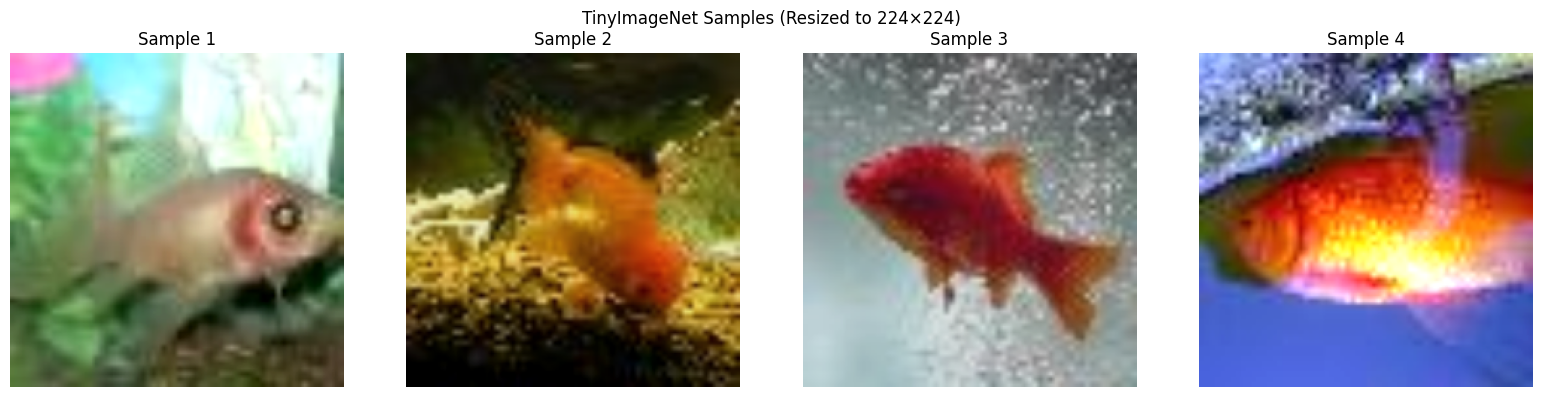

In [4]:
# Verify dataset with a sample
sample = train_dataset[0]
print(f"Sample shape: {sample.shape}")  # Should be [3, 224, 224]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i in range(4):
    img = inv_normalize(train_dataset[i])
    img = img.permute(1, 2, 0).clamp(0, 1).numpy()
    axes[i].imshow(img)
    axes[i].set_title(f"Sample {i+1}")
    axes[i].axis('off')
plt.suptitle("TinyImageNet Samples (Resized to 224×224)")
plt.tight_layout()
plt.show()

## Part 1: Patchification & Masking

# Cell 1.1 — PatchEmbed, patchify, unpatchify, random_masking


In [5]:
class PatchEmbed(nn.Module):
    """Split image into patches and embed them.

    Uses Conv2d as an efficient way to patchify:
    kernel_size=stride=patch_size extracts non-overlapping patches.
    """

    def __init__(self, img_size=224, patch_size=16, in_channels=3, embed_dim=768):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2  # 196
        # Conv2d acts as a linear projection of flattened patches
        self.proj = nn.Conv2d(in_channels, embed_dim,
                              kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        # x: (B, 3, 224, 224) -> (B, embed_dim, 14, 14)
        x = self.proj(x)
        # Flatten spatial dims and transpose: (B, embed_dim, 14, 14) -> (B, 196, embed_dim)
        x = x.flatten(2).transpose(1, 2)
        return x


def patchify(imgs, patch_size=16):
    """Convert images to patches for loss computation.

    Args:
        imgs: (B, 3, H, W)
    Returns:
        patches: (B, num_patches, patch_size**2 * 3)
    """
    B, C, H, W = imgs.shape
    h = w = H // patch_size
    # Reshape to (B, C, h, patch_size, w, patch_size)
    x = imgs.reshape(B, C, h, patch_size, w, patch_size)
    # Permute to (B, h, w, patch_size, patch_size, C)
    x = x.permute(0, 2, 4, 3, 5, 1)
    # Flatten to (B, h*w, patch_size*patch_size*C)
    x = x.reshape(B, h * w, patch_size * patch_size * C)
    return x


def unpatchify(patches, patch_size=16, img_size=224):
    """Convert patches back to images.

    Args:
        patches: (B, num_patches, patch_size**2 * 3)
    Returns:
        imgs: (B, 3, H, W)
    """
    B = patches.shape[0]
    h = w = img_size // patch_size
    C = 3
    # Reshape to (B, h, w, patch_size, patch_size, C)
    x = patches.reshape(B, h, w, patch_size, patch_size, C)
    # Permute to (B, C, h, patch_size, w, patch_size)
    x = x.permute(0, 5, 1, 3, 2, 4)
    # Reshape to (B, C, H, W)
    x = x.reshape(B, C, img_size, img_size)
    return x


def random_masking(x, mask_ratio=0.75):
    """Perform random masking by per-sample shuffling.

    Args:
        x: (B, N, D) - patch embeddings
        mask_ratio: fraction of patches to mask
    Returns:
        x_visible: (B, N_visible, D) - visible patch embeddings
        mask: (B, N) - binary mask, 0=keep, 1=mask
        ids_restore: (B, N) - indices to restore original ordering
        ids_keep: (B, N_visible) - indices of kept patches
    """
    B, N, D = x.shape
    num_keep = int(N * (1 - mask_ratio))

    # Generate random noise for sorting
    noise = torch.rand(B, N, device=x.device)

    # Sort noise: ascending order means smaller values = kept
    ids_shuffle = torch.argsort(noise, dim=1)
    ids_restore = torch.argsort(ids_shuffle, dim=1)

    # Keep first num_keep indices
    ids_keep = ids_shuffle[:, :num_keep]

    # Gather visible patches
    x_visible = torch.gather(x, dim=1, index=ids_keep.unsqueeze(-1).expand(-1, -1, D))

    # Generate binary mask: 0 = keep, 1 = mask
    mask = torch.ones(B, N, device=x.device)
    mask[:, :num_keep] = 0
    # Unshuffle to get mask in original patch order
    mask = torch.gather(mask, dim=1, index=ids_restore)

    return x_visible, mask, ids_restore, ids_keep


# Quick test
print("=== Patchification & Masking Test ===")
dummy_img = torch.randn(2, 3, 224, 224)
patch_embed = PatchEmbed()
patches = patch_embed(dummy_img)
print(f"Patch embeddings shape: {patches.shape}")  # (2, 196, 768)

visible, mask, ids_restore, ids_keep = random_masking(patches, mask_ratio=0.75)
print(f"Visible patches shape: {visible.shape}")  # (2, 49, 768)
print(f"Mask shape: {mask.shape}, masked count: {mask.sum(dim=1)}")  # (2, 196), 147 each
print(f"ids_restore shape: {ids_restore.shape}")  # (2, 196)

# Test patchify / unpatchify roundtrip
p = patchify(dummy_img, 16)
reconstructed = unpatchify(p, 16, 224)
print(f"Patchify/Unpatchify roundtrip error: {(dummy_img - reconstructed).abs().max():.6f}")

=== Patchification & Masking Test ===
Patch embeddings shape: torch.Size([2, 196, 768])
Visible patches shape: torch.Size([2, 49, 768])
Mask shape: torch.Size([2, 196]), masked count: tensor([147., 147.])
ids_restore shape: torch.Size([2, 196])
Patchify/Unpatchify roundtrip error: 0.000000


## Part 2: Transformer Building Blocks

# Cell 2.1 — MultiHeadSelfAttention, MLP, TransformerBlock


In [6]:
class MultiHeadSelfAttention(nn.Module):
    """Multi-Head Self-Attention (MHSA).

    Implements scaled dot-product attention with multiple heads.
    """

    def __init__(self, embed_dim, num_heads, qkv_bias=True, attn_drop=0., proj_drop=0.):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.scale = self.head_dim ** -0.5

        # Single linear layer for Q, K, V projections
        self.qkv = nn.Linear(embed_dim, embed_dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x):
        B, N, C = x.shape
        # Compute Q, K, V: (B, N, 3*C) -> (3, B, num_heads, N, head_dim)
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)

        # Scaled dot-product attention
        attn = (q @ k.transpose(-2, -1)) * self.scale  # (B, heads, N, N)
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        # Apply attention to values
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)  # (B, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x


class MLP(nn.Module):
    """Feed-Forward Network (FFN) with GELU activation."""

    def __init__(self, in_features, hidden_features=None, out_features=None, drop=0.):
        super().__init__()
        hidden_features = hidden_features or in_features * 4
        out_features = out_features or in_features
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_features, out_features)
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x


class TransformerBlock(nn.Module):
    """Transformer block with Pre-LayerNorm architecture.

    Pre-LN: LayerNorm -> Attention -> Residual -> LayerNorm -> MLP -> Residual
    (more stable for training, used in ViT and MAE)
    """

    def __init__(self, embed_dim, num_heads, mlp_ratio=4.0,
                 qkv_bias=True, drop=0., attn_drop=0.):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadSelfAttention(embed_dim, num_heads,
                                            qkv_bias=qkv_bias,
                                            attn_drop=attn_drop,
                                            proj_drop=drop)
        self.norm2 = nn.LayerNorm(embed_dim)
        mlp_hidden = int(embed_dim * mlp_ratio)
        self.mlp = MLP(embed_dim, hidden_features=mlp_hidden, drop=drop)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x


# Quick test
print("=== Transformer Block Test ===")
block = TransformerBlock(embed_dim=768, num_heads=12)
dummy_tokens = torch.randn(2, 49, 768)
out = block(dummy_tokens)
print(f"Input: {dummy_tokens.shape} -> Output: {out.shape}")  # (2, 49, 768)

params = sum(p.numel() for p in block.parameters())
print(f"Single block params: {params:,}")

=== Transformer Block Test ===
Input: torch.Size([2, 49, 768]) -> Output: torch.Size([2, 49, 768])
Single block params: 7,087,872


## Part 3: ViT Encoder (ViT-Base B/16)

#  Cell 3.1 — ViTEncoder Class


In [7]:
class ViTEncoder(nn.Module):
    """Vision Transformer Encoder (ViT-Base configuration).

    - Processes ONLY visible patches (not masked ones)
    - Does NOT use mask tokens
    - Adds positional embeddings only for visible patch positions
    """

    def __init__(self, img_size=224, patch_size=16, in_channels=3,
                 embed_dim=768, depth=12, num_heads=12,
                 mlp_ratio=4.0, qkv_bias=True, drop_rate=0., attn_drop_rate=0.):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size, patch_size, in_channels, embed_dim)
        self.num_patches = self.patch_embed.num_patches
        self.embed_dim = embed_dim

        # Learnable positional embeddings for all patches
        self.pos_embed = nn.Parameter(
            torch.zeros(1, self.num_patches, embed_dim))

        # Transformer blocks
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, mlp_ratio,
                             qkv_bias, drop_rate, attn_drop_rate)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)

        # Initialize positional embeddings
        self._init_pos_embed()
        self.apply(self._init_weights)

    def _init_pos_embed(self):
        """Initialize positional embeddings with sinusoidal pattern."""
        pos_embed = get_2d_sincos_pos_embed(
            self.embed_dim,
            int(self.num_patches ** 0.5)
        )
        self.pos_embed.data.copy_(torch.from_numpy(pos_embed).float().unsqueeze(0))

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)

    def forward(self, x, ids_keep):
        """
        Args:
            x: (B, 3, H, W) input image
            ids_keep: (B, N_visible) indices of visible patches
        Returns:
            latent: (B, N_visible, embed_dim) encoder features
            mask: (B, N) binary mask
            ids_restore: (B, N) indices to restore ordering
        """
        # Patch embedding
        x = self.patch_embed(x)  # (B, 196, 768)

        # Add positional embeddings (before masking)
        x = x + self.pos_embed

        # Apply masking: keep only visible patches
        x, mask, ids_restore, ids_keep = random_masking(x, MASK_RATIO)

        # Forward through transformer blocks
        for block in self.blocks:
            x = block(x)

        x = self.norm(x)
        return x, mask, ids_restore

## Part 4: ViT Decoder (ViT-Small S/16)


# Cell 4.1 — ViTDecoder Class


In [8]:
class ViTDecoder(nn.Module):
    """Vision Transformer Decoder (ViT-Small configuration).

    Receives:
    - Encoded visible patch tokens (projected to decoder dim)
    - Learnable mask tokens for missing patches
    Reconstructs all patches including masked ones.
    """

    def __init__(self, num_patches=196, patch_size=16,
                 encoder_embed_dim=768, decoder_embed_dim=384,
                 depth=12, num_heads=6, mlp_ratio=4.0,
                 qkv_bias=True, drop_rate=0., attn_drop_rate=0.):
        super().__init__()
        self.num_patches = num_patches
        self.decoder_embed_dim = decoder_embed_dim

        # Project encoder output to decoder dimension
        self.decoder_embed = nn.Linear(encoder_embed_dim, decoder_embed_dim, bias=True)

        # Learnable mask token
        self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_embed_dim))

        # Positional embeddings for decoder (all patches)
        self.decoder_pos_embed = nn.Parameter(
            torch.zeros(1, num_patches, decoder_embed_dim))

        # Decoder transformer blocks
        self.blocks = nn.ModuleList([
            TransformerBlock(decoder_embed_dim, num_heads, mlp_ratio,
                             qkv_bias, drop_rate, attn_drop_rate)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(decoder_embed_dim)

        # Prediction head: project back to pixel space
        self.pred = nn.Linear(decoder_embed_dim, patch_size ** 2 * 3, bias=True)

        # Initialize
        self._init_pos_embed()
        nn.init.normal_(self.mask_token, std=0.02)
        self.apply(self._init_weights)

    def _init_pos_embed(self):
        pos_embed = get_2d_sincos_pos_embed(
            self.decoder_embed_dim,
            int(self.num_patches ** 0.5)
        )
        self.decoder_pos_embed.data.copy_(
            torch.from_numpy(pos_embed).float().unsqueeze(0))

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)

    def forward(self, x, ids_restore):
        """
        Args:
            x: (B, N_visible, encoder_embed_dim) encoder output
            ids_restore: (B, N) indices to restore original ordering
        Returns:
            pred: (B, N, patch_size**2 * 3) predicted pixel patches
        """
        # Project encoder tokens to decoder dimension
        x = self.decoder_embed(x)  # (B, N_visible, decoder_embed_dim)

        # Append mask tokens
        B, N_vis, D = x.shape
        N = self.num_patches
        mask_tokens = self.mask_token.expand(B, N - N_vis, -1)  # (B, N_masked, D)
        x_ = torch.cat([x, mask_tokens], dim=1)  # (B, N, D) — visible first, then masks

        # Unshuffle: restore to original patch ordering
        x = torch.gather(x_, dim=1,
                          index=ids_restore.unsqueeze(-1).expand(-1, -1, D))

        # Add positional embeddings
        x = x + self.decoder_pos_embed

        # Forward through transformer blocks
        for block in self.blocks:
            x = block(x)

        x = self.norm(x)

        # Predict pixel values
        x = self.pred(x)  # (B, N, patch_size**2 * 3)
        return x

## Part 5: Full Masked Autoencoder Model


# Cell 5.1 — Positional Embeddings & MaskedAutoencoder Class


In [9]:
def get_2d_sincos_pos_embed(embed_dim, grid_size):
    """Generate 2D sinusoidal positional embeddings.

    Args:
        embed_dim: embedding dimension
        grid_size: int, grid height and width (e.g., 14 for 14x14 patches)
    Returns:
        pos_embed: (grid_size*grid_size, embed_dim)
    """
    grid_h = np.arange(grid_size, dtype=np.float32)
    grid_w = np.arange(grid_size, dtype=np.float32)
    grid = np.meshgrid(grid_w, grid_h)  # (2, grid_size, grid_size)
    grid = np.stack(grid, axis=0).reshape(2, -1)  # (2, grid_size^2)

    emb_h = get_1d_sincos_pos_embed(embed_dim // 2, grid[1])  # (grid_size^2, D/2)
    emb_w = get_1d_sincos_pos_embed(embed_dim // 2, grid[0])  # (grid_size^2, D/2)
    pos_embed = np.concatenate([emb_h, emb_w], axis=1)  # (grid_size^2, D)
    return pos_embed


def get_1d_sincos_pos_embed(embed_dim, positions):
    """Generate 1D sinusoidal positional embeddings.

    Args:
        embed_dim: output dimension for each position
        positions: array of positions
    Returns:
        emb: (len(positions), embed_dim)
    """
    assert embed_dim % 2 == 0
    omega = np.arange(embed_dim // 2, dtype=np.float64)
    omega /= embed_dim / 2.0
    omega = 1.0 / (10000 ** omega)

    positions = positions.reshape(-1)
    out = np.einsum('m,d->md', positions, omega)

    emb_sin = np.sin(out)
    emb_cos = np.cos(out)
    emb = np.concatenate([emb_sin, emb_cos], axis=1)  # (M, D)
    return emb


class MaskedAutoencoder(nn.Module):
    """Masked Autoencoder with asymmetric encoder-decoder architecture.

    Encoder: ViT-Base (768-dim, 12 layers, 12 heads, ~86M params)
    Decoder: ViT-Small (384-dim, 12 layers, 6 heads, ~22M params)
    """

    def __init__(self,
                 img_size=224,
                 patch_size=16,
                 in_channels=3,
                 # Encoder params (ViT-Base)
                 encoder_embed_dim=768,
                 encoder_depth=12,
                 encoder_num_heads=12,
                 # Decoder params (ViT-Small)
                 decoder_embed_dim=384,
                 decoder_depth=12,
                 decoder_num_heads=6,
                 # Common params
                 mlp_ratio=4.0,
                 mask_ratio=0.75):
        super().__init__()
        self.patch_size = patch_size
        self.img_size = img_size
        self.mask_ratio = mask_ratio
        self.num_patches = (img_size // patch_size) ** 2

        # ---------- Encoder ----------
        self.patch_embed = PatchEmbed(img_size, patch_size, in_channels, encoder_embed_dim)
        self.pos_embed = nn.Parameter(
            torch.zeros(1, self.num_patches, encoder_embed_dim))

        self.encoder_blocks = nn.ModuleList([
            TransformerBlock(encoder_embed_dim, encoder_num_heads, mlp_ratio)
            for _ in range(encoder_depth)
        ])
        self.encoder_norm = nn.LayerNorm(encoder_embed_dim)

        # ---------- Decoder ----------
        self.decoder_embed = nn.Linear(encoder_embed_dim, decoder_embed_dim, bias=True)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_embed_dim))
        self.decoder_pos_embed = nn.Parameter(
            torch.zeros(1, self.num_patches, decoder_embed_dim))

        self.decoder_blocks = nn.ModuleList([
            TransformerBlock(decoder_embed_dim, decoder_num_heads, mlp_ratio)
            for _ in range(decoder_depth)
        ])
        self.decoder_norm = nn.LayerNorm(decoder_embed_dim)

        # Prediction head: patch pixels
        self.decoder_pred = nn.Linear(
            decoder_embed_dim, patch_size ** 2 * in_channels, bias=True)

        # Initialize
        self._initialize_weights()

    def _initialize_weights(self):
        # Positional embeddings (sinusoidal)
        encoder_pos = get_2d_sincos_pos_embed(
            self.pos_embed.shape[-1], int(self.num_patches ** 0.5))
        self.pos_embed.data.copy_(torch.from_numpy(encoder_pos).float().unsqueeze(0))

        decoder_pos = get_2d_sincos_pos_embed(
            self.decoder_pos_embed.shape[-1], int(self.num_patches ** 0.5))
        self.decoder_pos_embed.data.copy_(
            torch.from_numpy(decoder_pos).float().unsqueeze(0))

        # Patch embed (like nn.Linear)
        w = self.patch_embed.proj.weight.data
        nn.init.xavier_uniform_(w.view(w.shape[0], -1))

        # Mask token
        nn.init.normal_(self.mask_token, std=0.02)

        # Apply to all other modules
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)

    def forward_encoder(self, x, mask_ratio):
        """Encode visible patches only.

        Args:
            x: (B, 3, H, W) input image
            mask_ratio: fraction of patches to mask
        Returns:
            latent: (B, N_visible, encoder_embed_dim)
            mask: (B, N) binary mask
            ids_restore: (B, N)
        """
        # Embed patches
        x = self.patch_embed(x)  # (B, N, D)

        # Add positional embeddings
        x = x + self.pos_embed

        # Random masking
        x, mask, ids_restore, _ = random_masking(x, mask_ratio)

        # Encoder transformer
        for block in self.encoder_blocks:
            x = block(x)
        x = self.encoder_norm(x)

        return x, mask, ids_restore

    def forward_decoder(self, x, ids_restore):
        """Decode: reconstruct all patches from visible latents + mask tokens.

        Args:
            x: (B, N_visible, encoder_embed_dim) encoder output
            ids_restore: (B, N) ordering indices
        Returns:
            pred: (B, N, patch_size**2 * 3) pixel predictions
        """
        # Project to decoder dimension
        x = self.decoder_embed(x)  # (B, N_visible, decoder_D)

        B, N_vis, D = x.shape
        N = self.num_patches

        # Append mask tokens for missing patches
        mask_tokens = self.mask_token.expand(B, N - N_vis, -1)
        x_ = torch.cat([x, mask_tokens], dim=1)  # (B, N, D)

        # Restore original ordering
        x = torch.gather(x_, dim=1,
                          index=ids_restore.unsqueeze(-1).expand(-1, -1, D))

        # Add decoder positional embeddings
        x = x + self.decoder_pos_embed

        # Decoder transformer
        for block in self.decoder_blocks:
            x = block(x)
        x = self.decoder_norm(x)

        # Predict pixel values per patch
        x = self.decoder_pred(x)  # (B, N, patch_size**2 * 3)
        return x

    def forward_loss(self, imgs, pred, mask):
        """Compute MSE loss on masked patches only.

        Args:
            imgs: (B, 3, H, W) original images
            pred: (B, N, patch_size**2 * 3) predicted patches
            mask: (B, N) binary mask (1=masked, 0=visible)
        Returns:
            loss: scalar, MSE on masked patches
        """
        target = patchify(imgs, self.patch_size)  # (B, N, P*P*3)

        # Normalize target per-patch (as in original MAE paper)
        mean = target.mean(dim=-1, keepdim=True)
        var = target.var(dim=-1, keepdim=True)
        target = (target - mean) / (var + 1e-6).sqrt()

        # MSE on all patches
        loss = (pred - target) ** 2
        loss = loss.mean(dim=-1)  # (B, N) per-patch loss

        # Only average over masked patches
        loss = (loss * mask).sum() / mask.sum()
        return loss

    def forward(self, imgs, mask_ratio=None):
        """Full forward pass.

        Args:
            imgs: (B, 3, H, W) input images
            mask_ratio: override mask ratio (default: self.mask_ratio)
        Returns:
            loss: reconstruction loss
            pred: (B, N, P*P*3) predictions
            mask: (B, N) binary mask
        """
        if mask_ratio is None:
            mask_ratio = self.mask_ratio

        latent, mask, ids_restore = self.forward_encoder(imgs, mask_ratio)
        pred = self.forward_decoder(latent, ids_restore)
        loss = self.forward_loss(imgs, pred, mask)
        return loss, pred, mask



# Cell 5.2 — Model Instantiation & Parameter Count

In [10]:
# === Model instantiation & parameter count ===

model = MaskedAutoencoder(
    img_size=IMAGE_SIZE,
    patch_size=PATCH_SIZE,
    in_channels=3,
    encoder_embed_dim=768,
    encoder_depth=12,
    encoder_num_heads=12,
    decoder_embed_dim=384,
    decoder_depth=12,
    decoder_num_heads=6,
    mlp_ratio=4.0,
    mask_ratio=MASK_RATIO,
)

# Count parameters
def count_params(module, name=""):
    total = sum(p.numel() for p in module.parameters())
    trainable = sum(p.numel() for p in module.parameters() if p.requires_grad)
    print(f"{name}: {total:,} total, {trainable:,} trainable")
    return total

encoder_params = sum(p.numel() for name, p in model.named_parameters()
                     if 'decoder' not in name and 'mask_token' not in name)
decoder_params = sum(p.numel() for name, p in model.named_parameters()
                     if 'decoder' in name or 'mask_token' in name)
total_params = sum(p.numel() for p in model.parameters())

print(f"Encoder parameters: {encoder_params:,} (~{encoder_params/1e6:.1f}M)")
print(f"Decoder parameters: {decoder_params:,} (~{decoder_params/1e6:.1f}M)")
print(f"Total parameters:   {total_params:,} (~{total_params/1e6:.1f}M)")

Encoder parameters: 85,797,120 (~85.8M)
Decoder parameters: 21,960,960 (~22.0M)
Total parameters:   107,758,080 (~107.8M)


# Cell 5.3 — Forward Pass Test


In [11]:
# Quick forward pass test
print("\n=== Forward Pass Test ===")
with torch.no_grad():
    test_imgs = torch.randn(2, 3, 224, 224)
    loss, pred, mask = model(test_imgs)
    print(f"Input:  {test_imgs.shape}")
    print(f"Pred:   {pred.shape}")  # (2, 196, 768)
    print(f"Mask:   {mask.shape}")  # (2, 196)
    print(f"Loss:   {loss.item():.4f}")
    print(f"Masked patches per image: {mask.sum(dim=1).tolist()}")


=== Forward Pass Test ===
Input:  torch.Size([2, 3, 224, 224])
Pred:   torch.Size([2, 196, 768])
Mask:   torch.Size([2, 196])
Loss:   1.6035
Masked patches per image: [147.0, 147.0]


## Part 6: Training Loop

# Cell 6.1 — Optimizer, Scheduler & Scaler Setup


In [12]:
# Move model to GPU(s)
if num_gpus > 1:
    model = nn.DataParallel(model)
model = model.to(device)

# Access base model for saving
base_model = model.module if isinstance(model, nn.DataParallel) else model

# Optimizer: AdamW
optimizer = torch.optim.AdamW(model.parameters(),
                               lr=LEARNING_RATE,
                               weight_decay=WEIGHT_DECAY,
                               betas=(0.9, 0.95))

# Scheduler: Cosine Annealing
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

# Mixed precision scaler
scaler = GradScaler()

# Gradient clipping value
MAX_GRAD_NORM = 1.0

/tmp/ipykernel_55/655258384.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


# Cell 6.2 — Training & Validation Functions


In [13]:
# === Training Function ===

def train_one_epoch(model, dataloader, optimizer, scaler, device, epoch):
    model.train()
    total_loss = 0.0
    num_batches = 0

    for batch_idx, images in enumerate(dataloader):
        images = images.to(device, non_blocking=True)

        optimizer.zero_grad()

        # Mixed precision forward
        with autocast():
            loss, pred, mask = model(images)
            loss = loss.mean()  # Handle DataParallel vector output

        # Mixed precision backward
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        num_batches += 1

        # Print progress every 100 batches
        if (batch_idx + 1) % 100 == 0:
            avg = total_loss / num_batches
            print(f"  Epoch {epoch+1} | Batch {batch_idx+1}/{len(dataloader)} | "
                  f"Loss: {loss.item():.4f} | Avg: {avg:.4f}")

    return total_loss / num_batches


@torch.no_grad()
def validate(model, dataloader, device):
    model.eval()
    total_loss = 0.0
    num_batches = 0

    for images in dataloader:
        images = images.to(device, non_blocking=True)
        with autocast():
            loss, pred, mask = model(images)
            loss = loss.mean()  # Handle DataParallel vector output
        total_loss += loss.item()
        num_batches += 1

    return total_loss / num_batches


# Cell 6.3 — Main Training Loop

In [14]:
# === Main Training Loop ===

train_losses = []
val_losses = []
best_val_loss = float('inf')

print("=" * 60)
print("Starting Training")
print("=" * 60)

for epoch in range(NUM_EPOCHS):
    # Train
    train_loss = train_one_epoch(model, train_loader, optimizer, scaler, device, epoch)
    train_losses.append(train_loss)

    # Validate
    val_loss = validate(model, val_loader, device)
    val_losses.append(val_loss)

    # Update LR
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] | "
          f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
          f"LR: {current_lr:.6f}")

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': base_model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': train_loss,
            'val_loss': val_loss,
        }, 'mae_best_model.pth')
        print(f"  ✓ Best model saved (val_loss: {val_loss:.4f})")

    # Save checkpoint every 10 epochs
    if (epoch + 1) % 10 == 0:
        torch.save({
            'epoch': epoch,
            'model_state_dict': base_model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'scaler_state_dict': scaler.state_dict(),
            'train_losses': train_losses,
            'val_losses': val_losses,
        }, f'mae_checkpoint_epoch{epoch+1}.pth')
        print(f"  ✓ Checkpoint saved at epoch {epoch+1}")

print("\n" + "=" * 60)
print(f"Training Complete! Best Val Loss: {best_val_loss:.4f}")
print("=" * 60)

Starting Training


/tmp/ipykernel_55/2713969000.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


  Epoch 1 | Batch 100/1562 | Loss: 0.8486 | Avg: 0.8901
  Epoch 1 | Batch 200/1562 | Loss: 0.7269 | Avg: 0.8408
  Epoch 1 | Batch 300/1562 | Loss: 0.6699 | Avg: 0.7926
  Epoch 1 | Batch 400/1562 | Loss: 0.6805 | Avg: 0.7620
  Epoch 1 | Batch 500/1562 | Loss: 0.6521 | Avg: 0.7428
  Epoch 1 | Batch 600/1562 | Loss: 0.6172 | Avg: 0.7284
  Epoch 1 | Batch 700/1562 | Loss: 0.6587 | Avg: 0.7177
  Epoch 1 | Batch 800/1562 | Loss: 0.6330 | Avg: 0.7078
  Epoch 1 | Batch 900/1562 | Loss: 0.5813 | Avg: 0.6977
  Epoch 1 | Batch 1000/1562 | Loss: 0.6350 | Avg: 0.6878
  Epoch 1 | Batch 1100/1562 | Loss: 0.6077 | Avg: 0.6793
  Epoch 1 | Batch 1200/1562 | Loss: 0.6168 | Avg: 0.6710
  Epoch 1 | Batch 1300/1562 | Loss: 0.5615 | Avg: 0.6636
  Epoch 1 | Batch 1400/1562 | Loss: 0.5544 | Avg: 0.6563
  Epoch 1 | Batch 1500/1562 | Loss: 0.5229 | Avg: 0.6493


/tmp/ipykernel_55/2713969000.py:45: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [1/50] | Train Loss: 0.6452 | Val Loss: 0.5443 | LR: 0.000300
  ✓ Best model saved (val_loss: 0.5443)
  Epoch 2 | Batch 100/1562 | Loss: 0.5009 | Avg: 0.5381
  Epoch 2 | Batch 200/1562 | Loss: 0.5427 | Avg: 0.5376
  Epoch 2 | Batch 300/1562 | Loss: 0.5155 | Avg: 0.5338
  Epoch 2 | Batch 400/1562 | Loss: 0.4683 | Avg: 0.5308
  Epoch 2 | Batch 500/1562 | Loss: 0.5085 | Avg: 0.5278
  Epoch 2 | Batch 600/1562 | Loss: 0.4947 | Avg: 0.5243
  Epoch 2 | Batch 700/1562 | Loss: 0.4952 | Avg: 0.5208
  Epoch 2 | Batch 800/1562 | Loss: 0.4974 | Avg: 0.5177
  Epoch 2 | Batch 900/1562 | Loss: 0.5158 | Avg: 0.5144
  Epoch 2 | Batch 1000/1562 | Loss: 0.4670 | Avg: 0.5112
  Epoch 2 | Batch 1100/1562 | Loss: 0.4671 | Avg: 0.5083
  Epoch 2 | Batch 1200/1562 | Loss: 0.4937 | Avg: 0.5055
  Epoch 2 | Batch 1300/1562 | Loss: 0.4839 | Avg: 0.5031
  Epoch 2 | Batch 1400/1562 | Loss: 0.4414 | Avg: 0.5003
  Epoch 2 | Batch 1500/1562 | Loss: 0.4829 | Avg: 0.4979
Epoch [2/50] | Train Loss: 0.4965 | Val Loss: 

KeyboardInterrupt: 

## Part 7: Visualization Module 

In [15]:
import os
print(os.listdir('/kaggle/working'))


['mae_checkpoint_epoch20.pth', '.virtual_documents', 'mae_best_model.pth', 'mae_checkpoint_epoch10.pth']


In [18]:
torch.save(model.state_dict(), 'manual_final_backup.pth')

In [19]:
from IPython.display import FileLink
FileLink(r'mae_best_model.pth')


/kaggle/working/mae_best_model.pth

In [22]:
import os

file_path = '/kaggle/working/mae_best_model.pth'
size_bytes = os.path.getsize(file_path)
size_mb = size_bytes / (1024 * 1024 * 1024)

print(f"Model Size: {size_mb:.2f} GB")


Model Size: 1.20 GB


# Cell 7.1 — Loss Plot


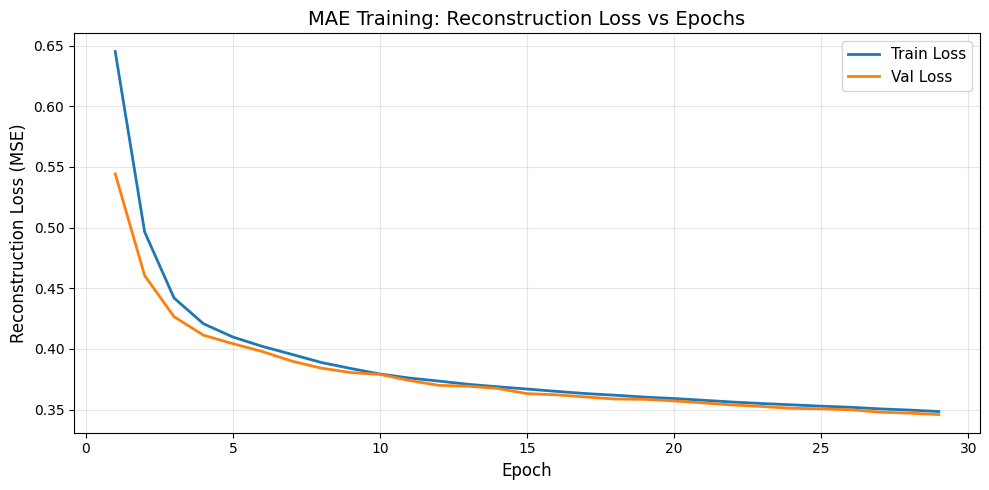

In [23]:
# === Loss Plot ===

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_losses)+1), train_losses, label='Train Loss', linewidth=2)
plt.plot(range(1, len(val_losses)+1), val_losses, label='Val Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Reconstruction Loss (MSE)', fontsize=12)
plt.title('MAE Training: Reconstruction Loss vs Epochs', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('loss_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# Cell 7.2 — Reconstruction Visualization (5 Samples)


Loaded best model from epoch 29


/tmp/ipykernel_55/4105041263.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


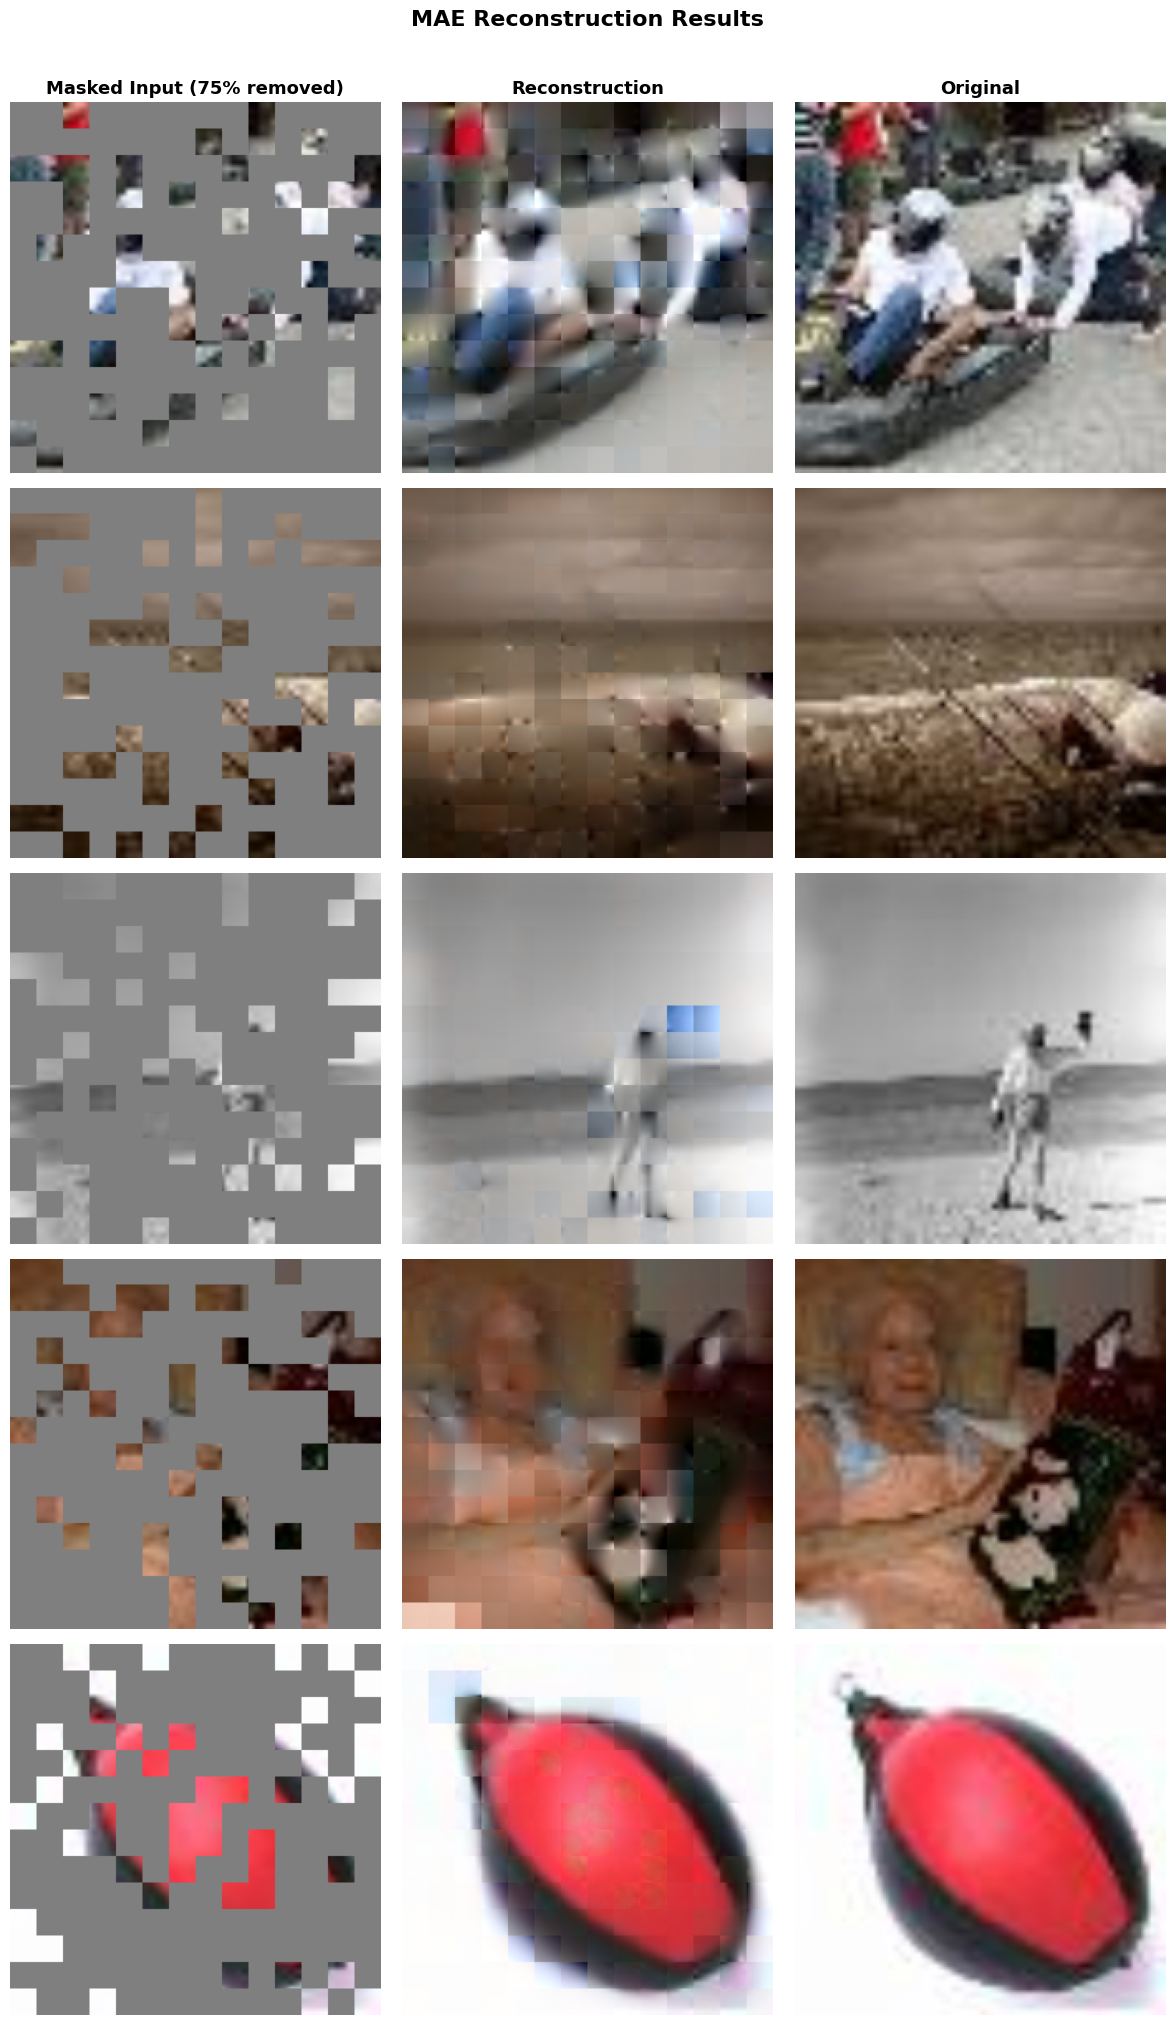

In [24]:
# === Reconstruction Visualization ===

@torch.no_grad()
def visualize_reconstruction(model, dataset, device, num_samples=5, mask_ratio=0.75):
    """Show masked input, reconstruction, and original for several images."""
    model.eval()
    base = model.module if isinstance(model, nn.DataParallel) else model
    patch_size = base.patch_size
    img_size = base.img_size

    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))
    col_titles = ['Masked Input (75% removed)', 'Reconstruction', 'Original']

    for i in range(num_samples):
        img = dataset[i].unsqueeze(0).to(device)  # (1, 3, H, W)

        with autocast():
            loss, pred, mask = base(img, mask_ratio=mask_ratio)

        # --- Original image ---
        orig = inv_normalize(img.squeeze(0).cpu())
        orig = orig.permute(1, 2, 0).clamp(0, 1).numpy()

        # --- Masked input visualization ---
        masked_img = create_masked_image(img.squeeze(0).cpu(), mask.squeeze(0).cpu(),
                                          patch_size, img_size)

        # --- Reconstructed image ---
        # Unnormalize predictions (reverse the per-patch normalization)
        target = patchify(img, patch_size)
        mean = target.mean(dim=-1, keepdim=True)
        var = target.var(dim=-1, keepdim=True)
        pred_unnorm = pred * (var + 1e-6).sqrt() + mean

        # For visualization: use predicted patches for masked, original for visible
        recon_patches = target.clone()
        mask_expanded = mask.squeeze(0).unsqueeze(-1).expand_as(recon_patches.squeeze(0))
        recon_patches[0, mask_expanded[..., 0].bool()] = \
            pred_unnorm[0, mask_expanded[..., 0].bool()]

        recon_img = unpatchify(recon_patches, patch_size, img_size)
        recon_img = inv_normalize(recon_img.squeeze(0).cpu())
        recon_img = recon_img.permute(1, 2, 0).clamp(0, 1).numpy()

        # Full reconstruction from predicted patches
        full_recon = unpatchify(pred_unnorm, patch_size, img_size)
        full_recon = inv_normalize(full_recon.squeeze(0).cpu())
        full_recon = full_recon.permute(1, 2, 0).clamp(0, 1).numpy()

        # Plot
        axes[i, 0].imshow(masked_img)
        axes[i, 1].imshow(full_recon)
        axes[i, 2].imshow(orig)

        for j in range(3):
            axes[i, j].axis('off')
            if i == 0:
                axes[i, j].set_title(col_titles[j], fontsize=13, fontweight='bold')

    plt.suptitle('MAE Reconstruction Results', fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('reconstruction_samples.png', dpi=150, bbox_inches='tight')
    plt.show()


def create_masked_image(img_tensor, mask, patch_size, img_size):
    """Create visualization of masked input image.

    Args:
        img_tensor: (3, H, W) normalized image tensor
        mask: (N,) binary mask (1=masked, 0=visible)
        patch_size: size of each patch
        img_size: full image size
    Returns:
        masked_img: (H, W, 3) numpy array for display
    """
    img = inv_normalize(img_tensor)
    img = img.permute(1, 2, 0).clamp(0, 1).numpy().copy()

    h = w = img_size // patch_size
    for idx in range(len(mask)):
        if mask[idx] == 1:  # masked
            row = idx // w
            col = idx % w
            y1, y2 = row * patch_size, (row + 1) * patch_size
            x1, x2 = col * patch_size, (col + 1) * patch_size
            img[y1:y2, x1:x2] = 0.5  # gray for masked

    return img


# Load best model and visualize
checkpoint = torch.load('mae_best_model.pth', map_location=device)
base_model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']+1}")

visualize_reconstruction(model, val_dataset, device, num_samples=5)

## Part 8: Quantitative Evaluation (PSNR & SSIM)

# Cell 8.1 — Metric Functions & Evaluation


In [25]:

def compute_psnr(img1, img2, max_val=1.0):
    """Compute Peak Signal-to-Noise Ratio between two images.

    Args:
        img1, img2: numpy arrays, shape (H, W, 3), range [0, 1]
        max_val: maximum pixel value
    Returns:
        psnr: float
    """
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * np.log10(max_val / np.sqrt(mse))


def compute_ssim(img1, img2, max_val=1.0):
    """Compute Structural Similarity Index (SSIM) between two images.

    Simplified version. For more accurate results, use skimage.

    Args:
        img1, img2: numpy arrays, shape (H, W, 3), range [0, 1]
    Returns:
        ssim: float
    """
    C1 = (0.01 * max_val) ** 2
    C2 = (0.03 * max_val) ** 2

    mu1 = img1.mean(axis=(0, 1))
    mu2 = img2.mean(axis=(0, 1))
    sigma1_sq = ((img1 - mu1) ** 2).mean(axis=(0, 1))
    sigma2_sq = ((img2 - mu2) ** 2).mean(axis=(0, 1))
    sigma12 = ((img1 - mu1) * (img2 - mu2)).mean(axis=(0, 1))

    ssim = ((2 * mu1 * mu2 + C1) * (2 * sigma12 + C2)) / \
           ((mu1 ** 2 + mu2 ** 2 + C1) * (sigma1_sq + sigma2_sq + C2))

    return ssim.mean()


@torch.no_grad()
def evaluate_metrics(model, dataset, device, num_samples=50, mask_ratio=0.75):
    """Compute PSNR and SSIM across multiple samples."""
    model.eval()
    base = model.module if isinstance(model, nn.DataParallel) else model
    patch_size = base.patch_size
    img_size = base.img_size

    psnr_scores = []
    ssim_scores = []

    indices = random.sample(range(len(dataset)), min(num_samples, len(dataset)))

    for idx in indices:
        img = dataset[idx].unsqueeze(0).to(device)

        with autocast():
            loss, pred, mask = base(img, mask_ratio=mask_ratio)

        # Unnormalize predictions
        target = patchify(img, patch_size)
        mean = target.mean(dim=-1, keepdim=True)
        var = target.var(dim=-1, keepdim=True)
        pred_unnorm = pred * (var + 1e-6).sqrt() + mean

        # Reconstruct images
        orig = inv_normalize(img.squeeze(0).cpu())
        orig = orig.permute(1, 2, 0).clamp(0, 1).numpy()

        recon = unpatchify(pred_unnorm, patch_size, img_size)
        recon = inv_normalize(recon.squeeze(0).cpu())
        recon = recon.permute(1, 2, 0).clamp(0, 1).numpy()

        psnr_scores.append(compute_psnr(orig, recon))
        ssim_scores.append(compute_ssim(orig, recon))

    print(f"\n{'='*50}")
    print(f"Quantitative Evaluation ({num_samples} samples)")
    print(f"{'='*50}")
    print(f"PSNR: {np.mean(psnr_scores):.2f} ± {np.std(psnr_scores):.2f} dB")
    print(f"SSIM: {np.mean(ssim_scores):.4f} ± {np.std(ssim_scores):.4f}")
    print(f"{'='*50}")

    return psnr_scores, ssim_scores


# Run evaluation
psnr_scores, ssim_scores = evaluate_metrics(model, val_dataset, device, num_samples=100)

/tmp/ipykernel_55/2764839179.py:57: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



Quantitative Evaluation (100 samples)
PSNR: 23.37 ± 3.23 dB
SSIM: 0.9202 ± 0.0558


# Cell 8.2 — Metrics Distribution Plot


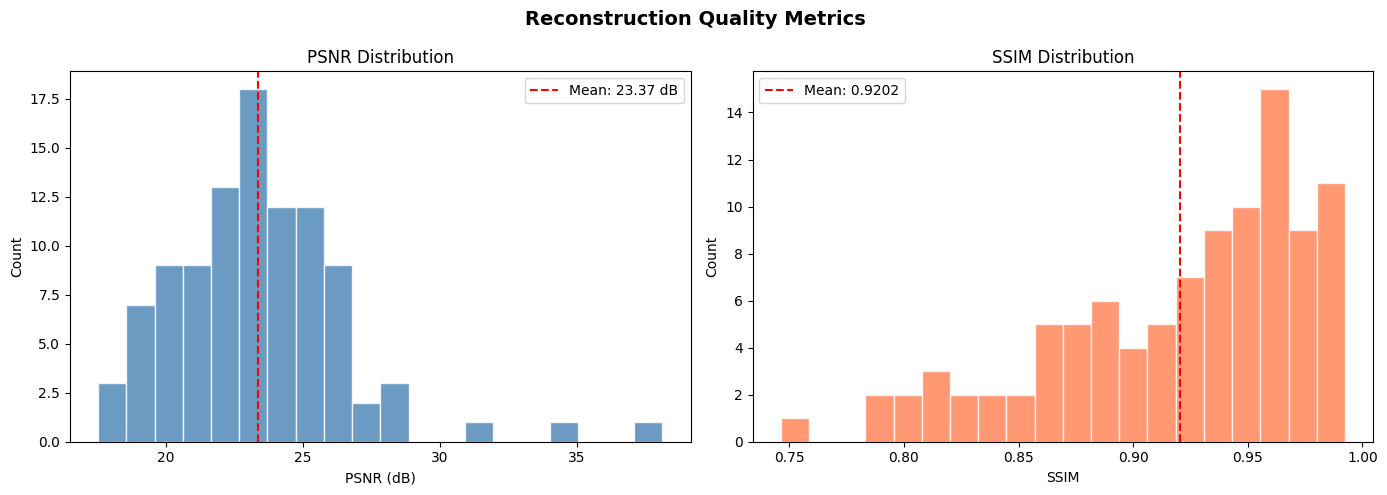

In [26]:
# Plot PSNR and SSIM distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(psnr_scores, bins=20, color='steelblue', edgecolor='white', alpha=0.8)
ax1.axvline(np.mean(psnr_scores), color='red', linestyle='--',
            label=f'Mean: {np.mean(psnr_scores):.2f} dB')
ax1.set_xlabel('PSNR (dB)')
ax1.set_ylabel('Count')
ax1.set_title('PSNR Distribution')
ax1.legend()

ax2.hist(ssim_scores, bins=20, color='coral', edgecolor='white', alpha=0.8)
ax2.axvline(np.mean(ssim_scores), color='red', linestyle='--',
            label=f'Mean: {np.mean(ssim_scores):.4f}')
ax2.set_xlabel('SSIM')
ax2.set_ylabel('Count')
ax2.set_title('SSIM Distribution')
ax2.legend()

plt.suptitle('Reconstruction Quality Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('metrics_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Part 9: Gradio App Deployment

This cell creates an interactive Gradio app for MAE inference.
You can also run this as a standalone script: `python gradio_app.py`

In [27]:
# === Gradio App for MAE Inference ===

import os
import torch
import torch.nn as nn
import numpy as np
import gradio as gr
from PIL import Image
from torchvision import transforms

# ---- Paste or import the MAE model classes here (or import from mae_assignment) ----
# If running standalone, you need to copy the model definitions above into this file,
# or use:  from mae_assignment import MaskedAutoencoder, patchify, unpatchify, ...
# For Kaggle notebook usage, this cell runs after all model definitions are available.


# ==================== APP SETUP ====================

# Normalization transforms
normalize = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

inv_normalize_fn = transforms.Compose([
    transforms.Normalize(mean=[0., 0., 0.],
                         std=[1/0.229, 1/0.224, 1/0.225]),
    transforms.Normalize(mean=[-0.485, -0.456, -0.406],
                         std=[1., 1., 1.]),
])


def load_model(checkpoint_path='mae_best_model.pth'):
    """Load the trained MAE model."""
    model = MaskedAutoencoder(
        img_size=224, patch_size=16, in_channels=3,
        encoder_embed_dim=768, encoder_depth=12, encoder_num_heads=12,
        decoder_embed_dim=384, decoder_depth=12, decoder_num_heads=6,
        mlp_ratio=4.0, mask_ratio=0.75,
    )

    if os.path.exists(checkpoint_path):
        checkpoint = torch.load(checkpoint_path, map_location='cpu')
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"✓ Model loaded from {checkpoint_path}")
    else:
        print(f"⚠ No checkpoint found at {checkpoint_path}. Using random weights.")

    model.eval()
    return model


# Load model globally
mae_model = load_model()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mae_model = mae_model.to(device)


def create_masked_visualization(img_tensor, mask, patch_size=16, img_size=224):
    """Create masked image for display."""
    img = inv_normalize_fn(img_tensor.cpu())
    img = img.permute(1, 2, 0).clamp(0, 1).numpy().copy()

    h = w = img_size // patch_size
    for idx in range(len(mask)):
        if mask[idx] == 1:
            row = idx // w
            col = idx % w
            y1, y2 = row * patch_size, (row + 1) * patch_size
            x1, x2 = col * patch_size, (col + 1) * patch_size
            img[y1:y2, x1:x2] = 0.5

    return (img * 255).astype(np.uint8)


def process_image(input_image, masking_ratio):
    """Process an uploaded image through the MAE model.

    Args:
        input_image: PIL Image from Gradio upload
        masking_ratio: float, fraction of patches to mask (0.0 to 0.95)
    Returns:
        Tuple of (masked_image, reconstruction, original) as numpy arrays
    """
    if input_image is None:
        return None, None, None

    # Convert to PIL if numpy
    if isinstance(input_image, np.ndarray):
        input_image = Image.fromarray(input_image)

    # Transform
    img_tensor = normalize(input_image)  # (3, 224, 224)
    img_batch = img_tensor.unsqueeze(0).to(device)  # (1, 3, 224, 224)

    # Forward pass
    with torch.no_grad():
        loss, pred, mask = mae_model(img_batch, mask_ratio=masking_ratio)

    # Original image
    orig = inv_normalize_fn(img_tensor)
    orig = orig.permute(1, 2, 0).clamp(0, 1).numpy()
    orig_display = (orig * 255).astype(np.uint8)

    # Masked image
    masked_display = create_masked_visualization(
        img_tensor, mask.squeeze(0).cpu(), patch_size=16, img_size=224)

    # Reconstruction
    target = patchify(img_batch, 16)
    mean = target.mean(dim=-1, keepdim=True)
    var = target.var(dim=-1, keepdim=True)
    pred_unnorm = pred * (var + 1e-6).sqrt() + mean

    recon_img = unpatchify(pred_unnorm, 16, 224)
    recon = inv_normalize_fn(recon_img.squeeze(0).cpu())
    recon = recon.permute(1, 2, 0).clamp(0, 1).numpy()
    recon_display = (recon * 255).astype(np.uint8)

    return masked_display, recon_display, orig_display


# ==================== GRADIO INTERFACE ====================

with gr.Blocks(
    title="Masked Autoencoder (MAE) — Image Reconstruction",
    theme=gr.themes.Soft(
        primary_hue="indigo",
        secondary_hue="violet",
    ),
    css="""
    .main-header {
        text-align: center;
        margin-bottom: 20px;
    }
    .output-images img {
        border-radius: 12px;
        border: 2px solid #e0e0e0;
    }
    """
) as demo:

    gr.Markdown("""
    # Masked Autoencoder (MAE)
    ### Self-Supervised Image Reconstruction
    
    Upload an image and adjust the masking ratio to see how the MAE reconstructs
    the masked portions. The model was trained on **TinyImageNet** with a **75% masking ratio**.
    
    ---
    """, elem_classes="main-header")

    with gr.Row():
        with gr.Column(scale=1):
            input_image = gr.Image(
                label=" Upload Image",
                type="pil",
                height=300,
            )
            mask_slider = gr.Slider(
                minimum=0.1,
                maximum=0.95,
                value=0.75,
                step=0.05,
                label=" Masking Ratio",
                info="Fraction of patches to mask (default: 0.75 = 75%)"
            )
            run_btn = gr.Button("🚀 Reconstruct", variant="primary", size="lg")

        with gr.Column(scale=2):
            with gr.Row():
                masked_output = gr.Image(label=" Masked Input", height=250)
                recon_output = gr.Image(label=" Reconstruction", height=250)
                orig_output = gr.Image(label=" Original", height=250)

    gr.Markdown("""
    ---
    **Architecture**: ViT-Base Encoder (~86M params) + ViT-Small Decoder (~22M params)  
    **Training**: AdamW + Cosine LR, MSE loss on masked patches only  
    **GenAI Assignment 02 — Spring 2026**
    """)

    # Event handlers
    run_btn.click(
        fn=process_image,
        inputs=[input_image, mask_slider],
        outputs=[masked_output, recon_output, orig_output],
    )

    # Also trigger on image upload
    input_image.change(
        fn=process_image,
        inputs=[input_image, mask_slider],
        outputs=[masked_output, recon_output, orig_output],
    )

    # Also trigger on slider change (if image is already uploaded)
    mask_slider.release(
        fn=process_image,
        inputs=[input_image, mask_slider],
        outputs=[masked_output, recon_output, orig_output],
    )

# Launch the app
print("\n Launching Gradio App...")
demo.launch(share=True, server_name="0.0.0.0")

✓ Model loaded from mae_best_model.pth


/tmp/ipykernel_55/2358791192.py:127: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(
/tmp/ipykernel_55/2358791192.py:127: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(



 Launching Gradio App...
* Running on local URL:  http://0.0.0.0:7860
* Running on public URL: https://ee6c4163b2a2c5dca0.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Cell 9 — Summary
# 
# | Metric | Value |
# |--------|-------|
# | Architecture | MAE (ViT-Base Encoder + ViT-Small Decoder) |
# | Encoder | 768-dim, 12 layers, 12 heads (~86M params) |
# | Decoder | 384-dim, 12 layers, 6 heads (~22M params) |
# | Mask Ratio | 75% |
# | Loss Function | MSE (masked patches only) |
# | Optimizer | AdamW |
# | Scheduler | Cosine Annealing |
# | Dataset | TinyImageNet (200 classes) |